In [ ]:
#Code visant à calculer la VaR paramétrique SUR UNE ACTION
from beartype import beartype
import pandas as pd
from scipy import stats
from math import *

@beartype
def VaR_parametrique(cours_action:float,quantite_action:int, variations_log_pourcentage:pd.Series, seuil:float, nb_jours=20):
    """Calcul de la VaR paramétrique pour une position quelconque sur une action

    Args:
        cours_action (float): cours de l'actif
        quantite_action (int): quantité détenue de l'action
        variations_log_pourcentage (pd.Series): données des variations logarithmiques en pourcentage
        seuil (float): % de chances de subir une variation plus négative que le montant affiché par la VaR paramétrique
        nb_jours (int, optional): nombre de jours sur lequel on calcule la volatilité journalière. Defaults to 20.

    Returns:
        _type_: float
    """

    #1. Centrer et réduire les variations journalières en %
    variations_pourcentage_c_r = pd.Series(stats.zscore(variations_log_pourcentage))
    
    #2. Calcul de la volatilité pour un horizon de la VaR de {nb_jours} jours
    volatilite = variations_pourcentage_c_r.std()*sqrt(nb_jours)
    
    #3. Calcul du quantile théorique d'ordre {seuil}
    quantile_th = stats.norm.ppf(seuil)
    
    #4. Calcul de la VaR paramétrique
    valeur_VaR_parametrique = cours_action*quantite_action*volatilite*quantile_th
    print(f"VaR paramétrique : {valeur_VaR_parametrique:.2f}") 
    return round(valeur_VaR_parametrique,2)

I - Récupération des données et quelques statistiques descriptives
count    124.000000
mean     263.122149
std       12.162082
min      226.358551
25%      256.148235
50%      264.464996
75%      272.727318
max      285.922455
Name: Close, dtype: float64
count    123.000000
mean       0.078010
std        1.423648
min       -5.127415
25%       -0.533606
50%        0.078581
75%        0.612431
max        4.219290
Name: Variations %, dtype: float64
Skewness : -0.06635627791304159 | Kurtosis en excès : 2.3053832227660638


II - Tests de normalité : test de Jarque-Bera et test de Shapiro-Wilk
Statistique JB : 24.0955 | p-value JB : 0.0000
Statistique de Jarque-Bera à la main : 27.328572684711308
Statistique SW : 0.9446 | p-value SW : 0.0001


III - Visualisation de la distribution : Diagramme Q-Q


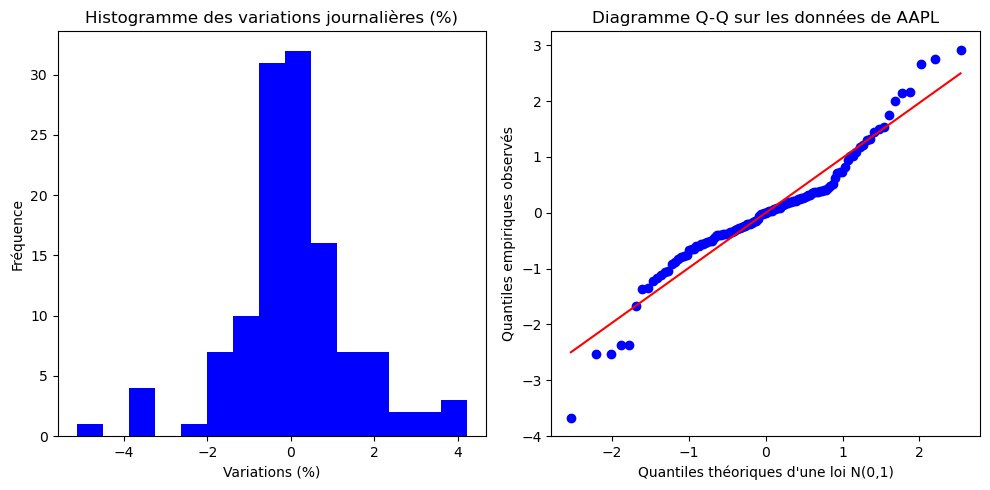

Le skewness est de -0.0664, et le kurtosis (en excès) est de 2.3054.
Bien que la distribution soit plutôt symétrique autour de sa moyenne 0.0780, la distribution est leptokurtique 
(=les queues sont plus épaisses).
Notamment, nous remarquons que les valeurs négatives extrêmes sont plus fréquentes que les valeurs positives extrêmes (variations de plus de 2%).

Le test de Shapiro-Wilk donne une p-value de 0,01% : nous pouvons rejeter l'hypothèse que les variations suivent une loi normale, au seuil de 1%.
Ainsi, l'hypothèse de normalité des variations, dans le calcul de la VaR paramétrique, n'est pas vérifiée empiriquement. 
Le calcul de la VaR paramétrique sous-estimerait les chances réelles de perdre montant plus grand que X, à un niveau de confiance 1-α donné.

Cela signifierait que, pour un niveau de confiance de 95%, la VaR paramétrique affirme qu'il y a 5% de chances de subir une variation plus négative que Z%.
Mais, nos données montreraient qu'il y aurait plutôt 5% de chances d'avo

In [1]:
#Objectif du code : vérifier la normalité des variations journalières pour vérifier s'il est raisonnable de calculer la VaR paramétrique.
#Les données sont recueillis sur l'action "AAPL" et sur la période "09/sep/2025" à "06/mar/2026".
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy import stats
from math import *




#I - Récupération des données et quelques statistiques descriptives
print("I - Récupération des données et quelques statistiques descriptives")

#Récupération des données du fichier Excel, et récupération des cours de clôture
df = pd.read_excel("C:/Users/kimis/OneDrive/Python for data analysis and finance/AAPL - data pour python.xlsx")
cours_cloture = df["Close"]
#print("Cours de clôture\n", cours_cloture)

#Création d'une nouvelle colonne/Series : calcul des variations journalières, en %.
df["Variations %"] = cours_cloture.apply(np.log).diff()*100
variations_pct = df["Variations %"].dropna()    
#On utilise la fonction "dropna()" pour supprimer la valeur NaN de la première ligne
#Cela est nécessaire pour avoir des données "propres".

#Affichage de quelques statistiques descriptives (moyenne, écart-type, min, max, quantiles à 25%, 50%, 75%)
cours_stats_descriptives = cours_cloture.describe()
variations_stats_descriptives = df["Variations %"].describe()
print(cours_stats_descriptives)
print(variations_stats_descriptives)

#Affichage du kurtosis et du skewness
print(f"Skewness : {variations_pct.skew()} | Kurtosis en excès : {variations_pct.kurtosis()}")





#II - Tests de noramlité : test de Jarque-Bera et test de Shapiro-Wilk
print("\n\nII - Tests de normalité : test de Jarque-Bera et test de Shapiro-Wilk")

#Test de Jarque-Bera
#Calcul de la statistique JB avec Python
stat_jb, p_value_jb = stats.jarque_bera(variations_pct)
print(f"Statistique JB : {stat_jb:.4f} | p-value JB : {p_value_jb:.4f}")
#Calcul de la statistique JB à la main
nb = len(variations_pct)
skewness = variations_pct.skew()
kurtosis = variations_pct.kurtosis()
stat_jb_main = (nb/6)*(skewness**2 + kurtosis**2/4)
print("Statistique de Jarque-Bera à la main :", stat_jb_main)
###

#Test de Shapiro-Wilk
stat_sw, p_value_sw = stats.shapiro(variations_pct)
print(f"Statistique SW : {stat_sw:.4f} | p-value SW : {p_value_sw:.4f}")

#Note : il y a ici que 123 observations, donc le test ne s'applique pas (le résultat du test est inutile),
#mais nous décidons quand même de le faire, simplement pour apprendre à l'utiliser.





#III - Visualisation de la distribution : Diagramme Q-Q
print("\n\nIII - Visualisation de la distribution : Diagramme Q-Q")

#On décide de centrer-réduire les données, de sorte à mieux interpréter les valeurs des quantiles dans le diagramme.
#On centre et réduit grâce à la fonction "zscore({données à centrer-réduire})"
variations_pct_centrees_reduites = stats.zscore(variations_pct)

#Création d'un cadre (fig) et d'une toile (ax) contenant 2 graphiques
fig, axes = plt.subplots(1,2)

#Dessin de l'histogramme des variations en %
variations_pct.plot(kind="hist",bins=15, figsize=(10,5), color="blue", ax=axes[0])
axes[0].set_title("Histogramme des variations journalières (%)")
axes[0].set_xlabel("Variations (%)")
axes[0].set_ylabel("Fréquence")

#Dessin du diagramme Q-Q, en utilisant la fonction "probplot({donnees},{distribution à comparer},{toile où dessiner})"
diagramme_Q_Q = stats.probplot(variations_pct_centrees_reduites,dist="norm",plot=axes[1])
axes[1].set_title("Diagramme Q-Q sur les données de AAPL")
axes[1].set_xlabel("Quantiles théoriques d'une loi N(0,1)")
axes[1].set_ylabel("Quantiles empiriques observés")

#Ajustement automatique de l'espace entre les deux graphiques et affichage des deux graphiques
plt.tight_layout()
plt.show()





#Conclusion de cette analyse
print(f"""Le skewness est de {skewness:.4f}, et le kurtosis (en excès) est de {kurtosis:.4f}.
Bien que la distribution soit plutôt symétrique autour de sa moyenne {variations_pct.mean():.4f}, la distribution est leptokurtique 
(=les queues sont plus épaisses).
Notamment, nous remarquons que les valeurs négatives extrêmes sont plus fréquentes que les valeurs positives extrêmes (variations de plus de 2%).""")
print(f"""\nLe test de Shapiro-Wilk donne une p-value de 0,01% : nous pouvons rejeter l'hypothèse que les variations suivent une loi normale, au seuil de 1%.
Ainsi, l'hypothèse de normalité des variations, dans le calcul de la VaR paramétrique, n'est pas vérifiée empiriquement. 
Le calcul de la VaR paramétrique sous-estimerait les chances réelles de perdre montant plus grand que X, à un niveau de confiance 1-α donné.

Cela signifierait que, pour un niveau de confiance de 95%, la VaR paramétrique affirme qu'il y a 5% de chances de subir une variation plus négative que Z%.
Mais, nos données montreraient qu'il y aurait plutôt 5% de chances d'avoir une variation plus négative que ???% (pour cela, il faut utiliser le quantile empirique d'ordre 5%).""")

In [ ]:
#Code visant à calculer la VaR historique
#Les données sont recueillis sur l'action "AAPL" et sur la période "09/sep/2025" à "06/mar/2026".
import pandas as pd, numpy as np
from beartype import beartype



#I - Récupération des données du fichier Excel, et récupération des cours de clôture
df = pd.read_excel("C:/Users/kimis/OneDrive/Python for data analysis and finance/AAPL - data pour python.xlsx")
cours_cloture = df["Close"]



#II- Création d'une nouvelle colonne/Series : calcul des variations journalières, en %.
df["Variations %"] = cours_cloture.apply(np.log).diff()*100
variations_pct = df["Variations %"].dropna()    
#On utilise la fonction "dropna()" pour supprimer la valeur NaN de la première ligne
#Cela est nécessaire pour avoir des données "propres".



#III - Calcul de la VaR historique.
#Note : on utilise la bibliothèque "beartype" pour s'assurer que les valeurs entrées dans les paramètres, par l'utilisateur, sont du bon type. 
@beartype
def VaR_historique(donnees: pd.Series, niveau_confiance=0.95, prudence=True):
    #Docstring de la fonction : définitions des paramètres.
    """Calcul de la VaR, à travers la méthode "historique".
    
    Si jamais le quantile de l'ordre souhaité n'est pas atteignable (= il n'existe pas de quantiles de cet ordre dans la base de données),
    alors l'utilisateur peut décider :
        - être "prudent" (prudence=True) : choisir le quantile inférieur le plus proche,
        - être "imprudent" (prudence=False) : choisir le quantile supérieur le plus proche.

    Args:
        donnees (pd.Series): variations de l'actif, en pourcentage
        niveau_confiance (float, optional): niveau de confiance pour le calcul du quantile. Defaults to 0.95.
        prudence (bool, optional): quantile inférieur le plus proche (True) / quantile supérieur le plus proche (False). Defaults to True.
    """

    #Etape 1 : trier les valeurs, et compter le nombre d'observations dans la base de données/sur la période considérée
    donnees_sorted = donnees.sort_values()
    nombre_variations = donnees_sorted.count()
    
    #Etape 2 : recherche de l'index "ordre" qui permet d'avoir la fréquence cumulée supérieure/inférieure la plus proche du seuil α
    frequence_cumulee = 0
    ordre = 0
    while frequence_cumulee < 1-niveau_confiance:
        ordre = ordre+1
        frequence_cumulee = ordre/nombre_variations
    
    #Après être sorti de la boucle, l'index actuel est celui de la fréquence cumulée supérieure la plus proche de α.
    if prudence==True:  #Cas "prudent" => recalcule la fréquence cumulée α' comme la fréquence cumulée inférieure la plus proche de α.
        ordre -= 1
        frequence_cumulee = ordre/nombre_variations
        niveau_confiance = 1-frequence_cumulee
    elif prudence==False:   #Cas "imprudent" => laisse la fréquence cumulée α' comme la fréquence cumulée supérieure la plus proche de α.
        pass

    #Etape 3 : calcul du quantile correspondant au seuil α', soit à un niveau de confiance de 1-α'.
    quantile = donnees_sorted.values[ordre-1]
    
    #Affichage du seuil α' et du niveau du quantile correspondant au niveau 1-α'.
    seuil = frequence_cumulee*100
    print(f"Seuil : {seuil:.2f}%\nQuantile à {niveau_confiance*100:.2f}% : {quantile:.4f}%")
    print(f"Si l'on détient pour 100 000€ de l'actif, il y a {seuil:.2f}% de chances que la perte maximale dépasse {quantile*100000/100:.2f}€")
    #Note : le quantile est exprimé en %, et non pas en valeur nominale (1% est ici : 1 au lieu de 0,01), 
    #donc on divise par 100 pour déterminer la perte maximale (écrire 1% comme "1" au lieu de "0,01" permettait simplement de mieux visualiser les variations).
    
VaR_historique(variations_pct)

Seuil : 4.88%
Quantile à 95.12% : -2.2996%
Si l'on détient pour 100 000€ de l'actif, il y a 4.88% de chances que la perte maximale dépasse -2299.58€


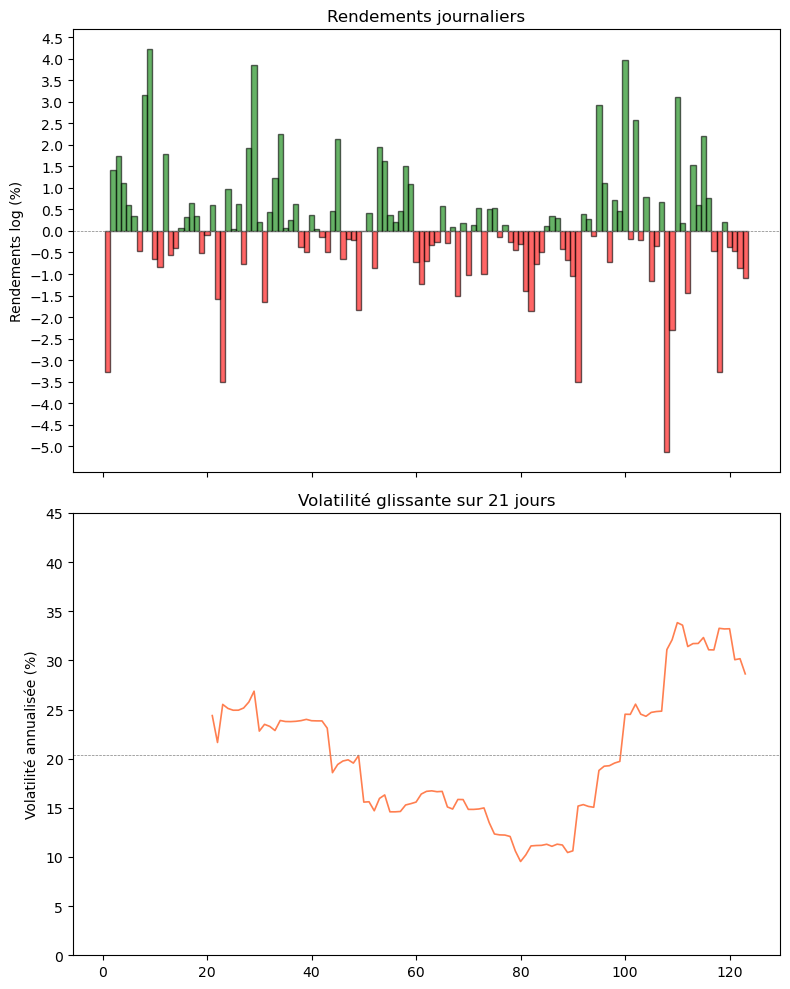

In [2]:
#VaR historique : outil graphique pour visualiser la stationnarité de la volatilité
#Objectif du code : déterminer graphiquement/visuellement si la volatilité est constante ou non
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from math import *



#I - Récupération des données du fichier Excel, et récupération des cours de clôture
df = pd.read_excel("C:/Users/kimis/OneDrive/Python for data analysis and finance/AAPL - data pour python.xlsx")
cours_cloture = df["Close"]



#II- Création d'une nouvelle colonne/Series : calcul des variations journalières, en %.
df["Variations %"] = cours_cloture.apply(np.log).diff()*100
variations_pct = df["Variations %"].dropna()    
#On utilise la fonction "dropna()" pour supprimer la valeur NaN de la première ligne
#Cela est nécessaire pour avoir des données "propres".



#III - Calcul de la volatilité glissante annualisée, sur des périodes de 21 jours, à l'aide de la fonction "rolling"
vol = variations_pct.rolling(window=21).std()*sqrt(252)
nombre_variations = variations_pct.count()




#IV.1 - Création du cadre des deux graphiques, et du code couleur des barres (qui vont refléter les variations positives et négatives)
colors = ["green" if variation>=0 else "red" for variation in variations_pct]
(fig, axes) = plt.subplots(nrows=2,ncols=1,figsize=(8,10), sharex=True)

#IV.2 - Premier graphique : graphique en bâtons montrant les variations journalières
axes[0].bar(x=variations_pct.index, height=variations_pct, color=colors, edgecolor="black", width=1, alpha=0.6)
axes[0].set_yticks(np.arange(-5,5,0.5)) #Affichage des unités de l'axe des ordonnées, allant de -5% à 5%, avec un pas de 0.5%
axes[0].axhline(0,color='gray', linewidth=0.5, linestyle='--')  #Dessin du trait horizontal du graphique, au niveau "rendements log=0"
axes[0].set_ylabel("Rendements log (%)")
axes[0].set_title("Rendements journaliers")

#IV.3 - Deuxième graphique : courbe de la volatilité annualisée, et droite horizontale au niveau de la moyenne des volatilités annualisées 
axes[1].plot(vol, color="coral", linewidth=1.2)
axes[1].set_yticks(np.arange(0,50,5))   #Affichage des unités de l'axe des ordonnées, allant de 0 à 50%, avec un pas de 5%
axes[1].axhline(vol.mean(), color="gray", linewidth=0.5, linestyle="--")    #Dessin du trait horizontal du graphique, au niveau "volatilité annuelle=moyenne de celle-ci" 
axes[1].set_ylabel("Volatilité annualisée (%)")
axes[1].set_title("Volatilité glissante sur 21 jours")

#IV.4 - Ajustement automatique de l'espace entre les deux graphiques et affichage des deux graphiques
plt.tight_layout()  
plt.show()

In [ ]:
#VaR historique : test ADF et test KPSS pour vérifier la stationnarité des rendements
from statsmodels.tsa import stattools
import pandas as pd, numpy as np
from math import *



#Récupération des données du fichier Excel, et récupération des cours de clôture
df = pd.read_excel("C:/Users/kimis/OneDrive/Python for data analysis and finance/AAPL - data pour python.xlsx")
cours_cloture = df["Close"]



#Création d'une nouvelle colonne/Series : calcul des variations journalières, en %.
df["Variations %"] = cours_cloture.apply(np.log).diff()*100
variations_pct = df["Variations %"].dropna()    
#On utilise la fonction "dropna()" pour supprimer la valeur NaN de la première ligne
#Cela est nécessaire pour avoir des données "propres".
#print(variations_pct)



#I - Test ADF
#H0 := il y a une racine unitaire (= non stationnarité)
#H1 := il n'y a pas de racine unitaire (= stationnarité)
test_ADF = stattools.adfuller(variations_pct,autolag="AIC")

print(f"Statistique ADF : {test_ADF[0]:.4f} | p-value : {test_ADF[1]:.4f}")
print(f"Valeurs critiques pour la loi de Dickey-Fuller :")
for seuil, valeur in test_ADF[4].items():
    print(f"   {seuil} : {valeur:.4f}")

print(f"""Dans le test ADF, la p-value vaut 0. Nous pouvons rejeter l'hypothèse H0 au seuil de 1% :
il n'y a pas de racine unitaire, donc les rendements sont stationnaires d'après le test ADF.""")



#II - Test KPSS
#H0 := la composante stochastique est stationnaire (= stationnarité)
#H1 := la composante stochastique n'est pas stationnaire (= non stationnarité)
stat_KPSS, pvalue_KPSS, lags, valeurs_critiques = stattools.kpss(variations_pct, regression='c', nlags='auto')
#Note : le paramètre "regression=" peut prendre deux valeurs : "c" et "ct"
#Si on écrit "regression=c" : on utilise le test "KPSS niveau", pour qui H0 := stationnarité autour d'une constante (qui est ce que l'on veut déterminer ici)
#Si on écrit "regression=ct" : on utilise le test "KPSS tendance", pour qui H0 := stationnarité autour d'une tendance linéaire (utile pour autre chose)

print(f"\nStatistique KPSS : {stat_KPSS:.4f} | p-value : {pvalue_KPSS:.4f} | lags retenus : {lags}")
print(f"Valeurs critiques :")
for seuil, valeur in valeurs_critiques.items():
    print(f"   {seuil} : {valeur:.3f}")
    
print(f"La statistique KPSS vaut {stat_KPSS:.4f}. Elle est bien plus petite que le seuil KPSS à 10% (qui vaut {list(valeurs_critiques.values())[0]}).")
print(f"Donc on ne peut pas rejeter l'hypothèse H0 au seuil de 10% (donc de 5% et 1%), et les rendements ci-présents sont stationnaires d'après le test KPSS.")


Statistique ADF : -9.6888 | p-value : 0.0000
Valeurs critiques pour la loi de Dickey-Fuller :
1% : -3.4851
5% : -2.8855
10% : -2.5796
Dans le test ADF, la p-value vaut 0. Nous pouvons rejeter l'hypothèse H0 au seuil de 1% :
il n'y a pas de racine unitaire, donc les rendements sont stationnaires d'après le test ADF.

Statistique KPSS : 0.2336 | p-value : 0.1000 | Lags retenus : 1
Valeurs critiques :
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
La statistique KPSS vaut 0.2336. Elle est bien plus petite que le seuil KPSS à 10% (qui vaut 0.347).
Donc on ne peut pas rejeter l'hypothèse H0 au seuil de 10% (donc de 5% et 1%), et les rendements ci-présents sont stationnaires d'après le test KPSS.


C:\Users\kimis\AppData\Local\Temp\ipykernel_24424\526286201.py:37: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat_KPSS, pvalue_KPSS, lags, valeurs_critiques = stattools.kpss(variations_pct, regression='c', nlags='auto')
